Signal Classification Project

This notebook demonstrates a simple machine learning pipeline for classifying synthetic signals into normal and defective classes.
The goal is to simulate an industrial anomaly detection scenario and apply basic feature-based classification.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

1. Data Generation

    We generate synthetic signals representing normal and defective conditions.
    Normal signals are smooth and noisy sinusoidal waves, while defective signals contain artificial spikes or distortions.

In [34]:
from src.generate_signals import generate_signal


# normal signal
#t1, s1 = generate_signal(defect=False)
normal_signals = []
for i in range(100):
    _, s = generate_signal(defect=False)
    normal_signals.append(s)

# defekte signal
#t2, s2 = generate_signal(defect=True)
defect_signals = []
for i in range(100):
    _, s = generate_signal(defect=True)
    defect_signals.append(s)



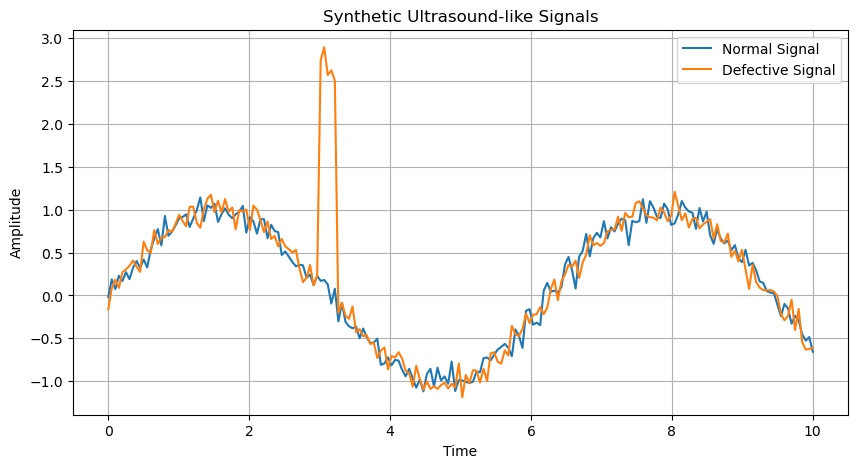

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(t1, s1, label="Normal Signal")
plt.plot(t2, s2, label="Defective Signal")

plt.title("Synthetic Ultrasound-like Signals")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.legend()
plt.grid(True)

plt.savefig("../results/Synthetic Ultrasound-like Signals.png")

plt.show()



2. Feature Extraction

    We extract statistical features from each signal to transform the time series into a feature vector suitable for machine learning.

In [39]:
from src.features import extract_features

X_normal = extract_features(normal_signals)
X_defect = extract_features(defect_signals)

X = np.vstack([X_normal, X_defect])
y = np.array([0] * len(X_normal) + [1] * len(X_defect))

In [40]:
import os
os.makedirs("data", exist_ok=True)

np.save("../data/X.npy", X)
np.save("../data/y.npy", y)

3. Train/Test Split

The dataset is split into training and testing sets to evaluate model performance.

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

4. Model Training
    A Random Forest classifier is used due to its robustness and ability to handle non-linear feature relationships.

In [42]:
from src.model import create_model

model = create_model()

#Or other Dataset possibel
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
y_pred = model.predict(X_test)

5. Evaluation

    Model performance is evaluated using a confusion matrix.

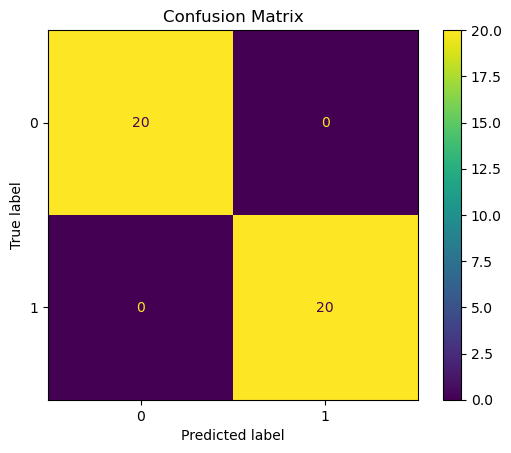

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")

plt.savefig("../results/confusion_matrix.png")

plt.show()

print(classification_report(y_test, y_pred))

4. Conclusion

    The model successfully distinguishes between normal and defective signals using simple statistical features.
    This demonstrates a full machine learning pipeline including data generation, feature extraction, model training, and evaluation.
    The approach can be extended to more realistic industrial signal processing tasks.